In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import json
import os
 
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
 

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv('Yahoo_Finance/Google/GOOG_historical_stock.csv')
 
print(df.head())
print(df.info())
print("Missing values per column:\n", df.isnull().sum())

         Date      Open      High       Low     Close  Adj Close     Volume
0  2004-08-19  2.490664  2.591785  2.390042  2.499133   2.477291  897427216
1  2004-08-20  2.515820  2.716817  2.503118  2.697639   2.674062  458857488
2  2004-08-23  2.758411  2.826406  2.716070  2.724787   2.700973  366857939
3  2004-08-24  2.770615  2.779581  2.579581  2.611960   2.589132  306396159
4  2004-08-25  2.614201  2.689918  2.587302  2.640104   2.617030  184645512
<class 'pandas.DataFrame'>
RangeIndex: 5524 entries, 0 to 5523
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       5524 non-null   str    
 1   Open       5524 non-null   float64
 2   High       5524 non-null   float64
 3   Low        5524 non-null   float64
 4   Close      5524 non-null   float64
 5   Adj Close  5524 non-null   float64
 6   Volume     5524 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 302.2 KB
None
Missing values per colum

In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
 
df = df.dropna().reset_index(drop=True)
 
TARGET_COL = 'Close'
prices = df[[TARGET_COL]].values 
 
print(f"Data range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total trading days: {len(df)}")

Data range: 2004-08-19 00:00:00 to 2026-08-04 00:00:00
Total trading days: 5524


In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)

In [5]:
LOOKBACK = 3      
HORIZON = 30      
 
def create_sequences(data, lookback, horizon):
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i : i + lookback, 0])          
        y.append(data[i + lookback + horizon - 1, 0])  
    return np.array(X), np.array(y)
 
X, y = create_sequences(scaled_prices, LOOKBACK, HORIZON)
 
X = X.reshape((X.shape[0], LOOKBACK, 1))
 
print("X shape:", X.shape)  # (number samples, 3, 1)
print("y shape:", y.shape)

X shape: (5492, 3, 1)
y shape: (5492,)


In [6]:
# Train/Test Split
split_idx = int(len(X) * 0.8)
 
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
 
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

Train samples: 4393, Test samples: 1099


In [7]:
# Build the LSTM Model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)  # predicted price 30 days ahead
])
 
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

2026-08-10 10:16:38.783059: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-08-10 10:16:38.783093: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-08-10 10:16:38.783098: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-08-10 10:16:38.783306: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-10 10:16:38.783314: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/salioudunn/Desktop/BootCamp/projects/MarketIQ/tensorflow-env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` ar

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 3, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


2026-08-10 10:16:39.980255: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.



  1/248 ━━━━━━━━━━━━━━━━━━━━ 13:13 3s/step - loss: 0.0037


  6/248 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0033 


 12/248 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0027

...


231/248 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7899e-04


235/248 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7688e-04


238/248 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7644e-04


244/248 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7459e-04


248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 3.7556e-04 - val_loss: 0.0161


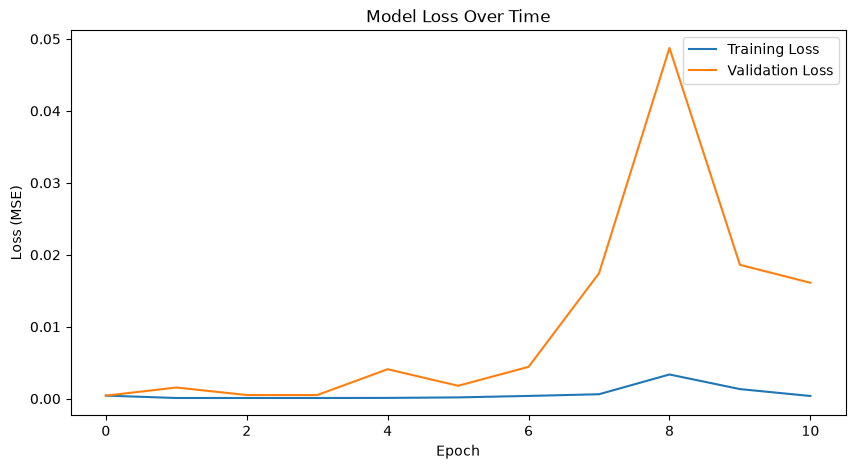

In [8]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
 
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)
 
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()


 1/35 ━━━━━━━━━━━━━━━━━━━━ 8s 249ms/step


31/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


RMSE: $21.77
MAE:  $15.40
MAPE: 8.31%


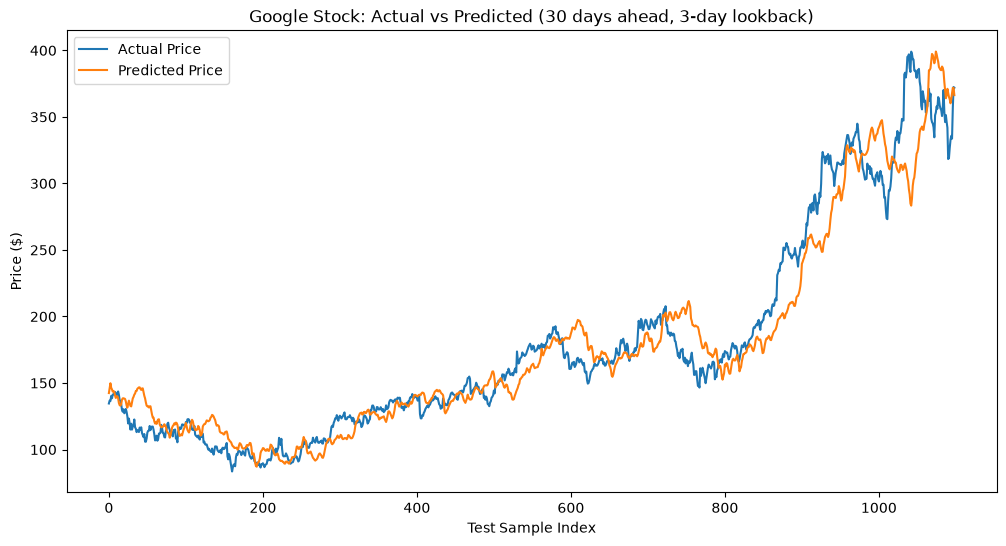

In [9]:
y_pred_scaled = model.predict(X_test)
 
# Inverse-transform back to real price scale
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
 
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae = mean_absolute_error(y_test_actual, y_pred)
mape = np.mean(np.abs((y_test_actual - y_pred) / y_test_actual)) * 100
 
print(f"RMSE: ${rmse:.2f}")
print(f"MAE:  ${mae:.2f}")
print(f"MAPE: {mape:.2f}%")
 
# Plot predictions vs actual
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')
plt.title(f'Google Stock: Actual vs Predicted (30 days ahead, {LOOKBACK}-day lookback)')
plt.xlabel('Test Sample Index')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

In [10]:
model.fit(X, y, epochs=len(history.history['loss']), batch_size=16, verbose=1)

Epoch 1/11



  1/344 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 2.3775e-04


  5/344 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0013    


 10/344 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0011


 15/344 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0017

...


325/344 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0016


331/344 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0016


337/344 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0016


342/344 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0016


344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0016


In [11]:
# os.makedirs("export", exist_ok=True)
 
# # 1. Save the trained model (frontend/backend team loads this for inference)
# model.save("export/google_lstm_model.keras")
 
# # 2. Save the scaler (REQUIRED to un-scale any future predictions correctly)
# joblib.dump(scaler, "export/price_scaler.pkl")
 
# # 3. Generate the next prediction using the most recent 3 real days of data
# last_window = scaled_prices[-LOOKBACK:].reshape(1, LOOKBACK, 1)
# next_pred_scaled = model.predict(last_window)
# next_pred_price = scaler.inverse_transform(next_pred_scaled)[0][0]
 
# last_date = df['Date'].max()
# target_date = last_date + pd.Timedelta(days=HORIZON)

In [12]:
# output_json = {
#     "ticker": "GOOGL",
#     "model_version": "1.0",
#     "last_known_date": last_date.strftime("%Y-%m-%d"),
#     "last_known_price": float(prices[-1][0]),
#     "prediction_target_date": target_date.strftime("%Y-%m-%d"),
#     "predicted_price": round(float(next_pred_price), 2),
#     "lookback_days": LOOKBACK,
#     "horizon_days": HORIZON,
#     "test_metrics": {
#         "rmse": round(float(rmse), 2),
#         "mae": round(float(mae), 2),
#         "mape_percent": round(float(mape), 2)
#     }
# }
 
# with open("export/latest_prediction.json", "w") as f:
#     json.dump(output_json, f, indent=2)
 
# print(json.dumps(output_json, indent=2))
# print("\nExported files in ./export/:")
# print(" - google_lstm_model.keras  (the trained model)")
# print(" - price_scaler.pkl         (needed to un-scale future predictions)")
# print(" - latest_prediction.json   (ready-to-use output for the frontend)")